In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import datasurfer as ds
import pandas as pd
import random
import torch
import matplotlib.pyplot as plt
import torch.nn as nn
import numpy as np
import torch.optim as optim
import optuna
import json
from torch import Tensor
from tqdm import tqdm
from sklearn.preprocessing import MinMaxScaler
from typing import List, Tuple
from torch.jit import ScriptModule, script_method
from datasurfer.lib_dlearn.utility import generate_3d_tensor
from pathlib import Path
from torch.optim.lr_scheduler import LambdaLR

NVIDIA RTX 3500 Ada Generation Laptop GPU


In [ ]:
configs = {
    'cond_net_layer': [1, 10],
    'cond_net_units': [2, 50],
    'ploss_net_layers': [1, 10],
    'ploss_net_units': [2, 50],
    'cond_activations': ["Sigmoid", "tanh", "linear", "ReLU", "biased Elu", "sinus"],
    'ploss_activations': ["Sigmoid", "tanh", "linear", "ReLU", "biased Elu", "sinus"],
    'lr': [1e-4, 1e-2],
    'lr_factor': [1e-2, 1e-1],
    'optimizer': ["Adam", "NAdam"],
    'loss_name': ["MSE"],
    'tbptt_size': [60, 1200],
    'sample_time': 0.5,
    'n_epochs': 500,
    'input_cols': ['nEm', 'tqEm', 'uDa', 'uQa', 'iDa', 'iQa', 'vfCoolt', 'vfeop', 'tCoolt', 'tNTC'],
    'target_cols': ['tOil', 'tWinding', 'tStator', 'tRotor'],
    'temperature_cols': ['tCoolt', 'tNTC', 'tOil', 'tWinding', 'tStator', 'tRotor'],
    'device': 'cpu',
    'run_mode': 'optimize'
}
json.dump(configs, open("configs.json", "w"), indent=4)

In [20]:
df_org = ds.AutoObject('RCP_dt05.csv', engine='polars').df
ids = df_org['ID']
cols = configs['input_cols'] + configs['target_cols']
tcols = configs['temperature_cols']
device = configs['device']

df_org.describe()

,ID,time,nEm,tqEm,uDa,uQa,iDa,iQa,vfeop,vfCoolt,tCoolt,tNTC,tOil,tWinding,tStator,tRotor
count,305843.000000,305843.000000,305843.000000,305843.000000,305843.000000,305843.000000,305843.000000,305843.000000,305843.000000,305843.000000,305843.000000,305843.000000,305843.000000,305843.000000,305843.000000,305843.000000
mean,41.499874,2418.459052,9140.340089,48.347342,-63.848836,107.733204,-84.430803,77.910731,6.559630,6.660625,25.669646,77.222646,59.667940,80.176166,87.768239,66.824219
std,24.246972,1899.056282,5039.021527,46.610758,55.711740,48.178045,37.891514,73.862395,3.483916,2.056988,35.131028,25.203870,25.371483,24.686451,28.381557,30.727268
min,0.000000,7.800000,494.000000,-100.914087,-126.562500,-0.375000,-203.932669,-162.750000,1.876907,3.500000,-21.200000,-7.753808,-9.700000,-7.399481,-8.437695,-2.450000
25%,20.500000,921.800000,5938.000000,28.375224,-99.875000,73.500000,-102.522112,45.687500,2.100000,3.500000,-19.700000,57.515625,42.100000,61.621028,67.617622,50.672067
50%,41.000000,1834.500000,7992.000000,44.864724,-74.349674,120.727524,-89.937500,75.450657,7.104442,8.000000,20.300000,80.886395,62.500000,84.352870,88.667195,70.800000
75%,62.000000,3427.600000,12995.000000,93.749590,-51.597664,148.695688,-63.116135,148.562500,7.300000,8.000000,64.600000,96.609375,80.600000,97.866667,110.597723,90.921620
max,83.000000,7299.000000,16999.000000,101.615040,162.189677,175.173121,-0.062500,165.312500,12.700000,8.200000,67.900000,133.223324,106.700000,132.659929,146.537551,117.749448


In [5]:

scaler = MinMaxScaler(feature_range = (-1, 1))
df_scaled = pd.DataFrame(scaler.fit_transform(df_org[cols]), columns=cols)
df_scaled.head()

,nEm,tqEm,uDa,uQa,iDa,iQa,vfCoolt,vfeop,tCoolt,tNTC,tOil,tWinding,tStator,tRotor
0,-0.940139,0.989131,-0.224948,-0.797702,0.512744,0.667109,0.914894,0.904203,0.952862,0.061519,0.146048,0.032098,-0.038848,0.000938
1,-0.937837,0.990248,-0.260523,-0.808028,0.129741,0.945417,0.914894,0.863291,0.952862,0.061797,0.144460,0.032408,-0.039585,0.001127
2,-0.938806,0.995548,-0.261469,-0.808457,0.120186,0.950115,0.914894,0.870289,0.952862,0.060744,0.144330,0.032205,-0.038993,0.001519
3,-0.938806,0.986525,-0.261477,-0.808457,0.121018,0.951768,0.914894,0.881471,0.952862,0.060731,0.144330,0.030681,-0.039145,0.002155
4,-0.938564,0.990137,-0.261477,-0.807873,0.120984,0.951991,0.914894,0.870647,0.952862,0.060851,0.144330,0.032844,-0.042044,0.002942


In [6]:
id_counts = ids.value_counts()
id_counts.describe()
valid_ids = id_counts.index.tolist()


In [7]:
random.seed(42)
train_ids = random.sample(list(valid_ids), int(0.8 * len(valid_ids)))
test_ids = [id for id in valid_ids if id not in train_ids]

In [8]:
train_tensor, train_sample_weights = generate_3d_tensor(df_scaled, ids, train_ids, device=device) 
train_tensor.shape, train_sample_weights.shape

(torch.Size([3641, 67, 14]), torch.Size([3641, 67]))

In [9]:
test_tensor, test_sample_weights = generate_3d_tensor(df_scaled, ids, test_ids, device=device) 
test_tensor.shape, test_sample_weights.shape

(torch.Size([3641, 17, 14]), torch.Size([3641, 17]))

In [10]:
df_scaled.columns

Index(['nEm', 'tqEm', 'uDa', 'uQa', 'iDa', 'iQa', 'vfCoolt', 'vfeop', 'tCoolt',
       'tNTC', 'tOil', 'tWinding', 'tStator', 'tRotor'],
      dtype='object')

In [11]:
p = Path(r'data')
p.mkdir(exist_ok=True, parents=True)
torch.save(train_tensor, p / "train_tensor.pt")
torch.save(train_sample_weights, p / "train_sample_weights.pt")
torch.save(test_tensor, p / "test_tensor.pt")
torch.save(test_sample_weights, p / "test_sample_weights.pt")

In [12]:
# Hyper parameters optimization 
# 自定义正弦激活层
class SinusLayer(nn.Module):
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return torch.sin(x)

def smooth_abs(x: torch.Tensor, epsilon: float = 1e-6) -> torch.Tensor:
    return torch.sqrt(x**2 + epsilon)

# 激活函数映射
def get_activation(activation_name: str) -> nn.Module:
    activation_dict = {
        "Sigmoid": nn.Sigmoid(),
        "tanh": nn.Tanh(),
        "linear": nn.Identity(),
        "ReLU": nn.ReLU(),
        "biased Elu": nn.ELU(alpha=1.0),
        "sinus": SinusLayer()
    }
    return activation_dict[activation_name]

def get_optimizer(optimizer_name: str, parameters, lr: float) -> optim.Optimizer:
    optimizer_dict = {
        "Adam": optim.Adam,
        "NAdam": optim.NAdam
    }
    return optimizer_dict[optimizer_name](parameters, lr=lr)

def get_loss_fn(loss_name: str) -> nn.Module:
    loss_dict = {
        "MSE": nn.MSELoss(),
    }
    return loss_dict[loss_name]

In [13]:
# TNNCell定义（支持动态结构和激活函数）
class TNNCell(nn.Module):
    def __init__(
                self, 
                cond_net_units, 
                cond_activations, 
                ploss_net_units, 
                ploss_activations, 
                sample_time, 
                input_cols, 
                target_cols, 
                temperature_cols):
        
        super().__init__()
        self.sample_time = sample_time
        self.output_size = len(target_cols)
        self.caps = nn.Parameter(torch.Tensor(self.output_size))
        nn.init.normal_(self.caps, mean=-9.2, std=0.5)
        
        n_temps = len(temperature_cols) # number of temperatures (targets and input)
        n_conds = int(0.5 * n_temps * (n_temps - 1)) # number of thermal conductances

        # 动态构建conductance_net
        cond_layers = []
        input_dim = len(input_cols) + self.output_size
        for i, units in enumerate(cond_net_units):
            cond_layers.append(nn.Linear(input_dim, units))
            # 使用当前层的激活函数
            cond_layers.append(get_activation(cond_activations[i]))
            input_dim = units
        cond_layers.append(nn.Linear(input_dim, n_conds))
        cond_layers.append(nn.Sigmoid())
        self.conductance_net = nn.Sequential(*cond_layers)

        # 动态构建ploss_net
        ploss_layers = []
        input_dim = len(input_cols) + self.output_size
        for i, units in enumerate(ploss_net_units):
            ploss_layers.append(nn.Linear(input_dim, units))
            ploss_layers.append(get_activation(ploss_activations[i]))
            input_dim = units
        ploss_layers.append(nn.Linear(input_dim, self.output_size))
        self.ploss = nn.Sequential(*ploss_layers)

        # 其余初始化代码
        self.adj_mat = np.zeros((n_temps, n_temps), dtype=int)
        triu_idx = np.triu_indices(n_temps, 1)
        adj_idx_arr = np.ones_like(self.adj_mat)
        adj_idx_arr = adj_idx_arr[triu_idx].ravel()
        self.adj_mat[triu_idx] = np.cumsum(adj_idx_arr) - 1
        self.adj_mat += self.adj_mat.T
        self.adj_mat = torch.from_numpy(self.adj_mat[:self.output_size, :]).type(torch.int64)
        self.temp_idcs = [i for i, x in enumerate(input_cols) if x in temperature_cols]

    def forward(self, inp: Tensor, hidden: Tensor) -> Tuple[Tensor, Tensor]:
        prev_out = hidden
        temps = torch.cat([prev_out, inp[:, self.temp_idcs]], dim=1)
        sub_nn_inp = torch.cat([inp, prev_out], dim=1)
        conducts = self.conductance_net(sub_nn_inp)
        power_loss = smooth_abs(self.ploss(sub_nn_inp))
        temp_diffs = torch.sum(
            (temps.unsqueeze(1) - prev_out.unsqueeze(-1)) * conducts[:, self.adj_mat],
            dim=-1,
        )
        out = prev_out + self.sample_time * torch.exp(self.caps) * (temp_diffs + power_loss)
        return prev_out, torch.clip(out, -1, 5)

In [14]:
# DiffEqLayer定义（支持TorchScript）
class DiffEqLayer(ScriptModule):
    def __init__(self, cell_module):
        super().__init__()
        self.cell = cell_module
        
    @script_method
    def forward(self, input: Tensor, state: Tensor) -> Tuple[Tensor, Tensor]:
        inputs = input.unbind(0)
        outputs = []
        for i in range(len(inputs)):
            out, state = self.cell(inputs[i], state)
            outputs.append(out)
        return torch.stack(outputs), state

In [15]:
def train_nn(**kwargs):
    model = kwargs.pop("model", None)
    cond_net_layers = kwargs.pop("cond_net_layers", 3)
    cond_net_units = kwargs.pop("cond_net_units", [20] * cond_net_layers)
    ploss_net_layers = kwargs.pop("ploss_net_layers", 2)
    ploss_net_units = kwargs.pop("ploss_net_units", [20] * ploss_net_layers)
    cond_activations = kwargs.pop("cond_activations", ["Sigmoid"] * cond_net_layers)
    ploss_activations = kwargs.pop("ploss_activations", ["tanh"] * ploss_net_layers)
    sample_time = kwargs.pop("sample_time", configs['sample_time'])
    input_cols = kwargs.pop("input_cols", configs['input_cols'])
    target_cols = kwargs.pop("target_cols", configs['target_cols'])
    temperature_cols = kwargs.pop("temperature_cols", configs['temperature_cols'])
    lr = kwargs.pop("lr", 1e-3)
    lr_factor = kwargs.pop("lr_factor", 1e-2)
    optimizer_name = kwargs.pop("optimizer", "Adam")
    loss_name = kwargs.pop("loss_name", "MSE")
    tbptt_size = kwargs.pop("tbptt_size", 512)
    n_epochs = kwargs.pop("n_epochs", 100)
    trial = kwargs.pop("trial", None)
    device = kwargs.pop("device", "cpu")

    if not model:
        # 构建模型（传递激活函数列表）
        tnn_cell = TNNCell(
            cond_net_units, cond_activations,  # 传递列表
            ploss_net_units, ploss_activations,  # 传递列表
            sample_time, input_cols, target_cols, temperature_cols
        ).to(device)
        model = DiffEqLayer(tnn_cell).to(device)

    # 3. 选择优化器
    opt = get_optimizer(optimizer_name, model.parameters(), lr)

    loss_func = get_loss_fn(loss_name)
    best_train_loss = float('inf')

    for epoch in range(n_epochs):
        hidden = train_tensor[0, :, -len(target_cols):]
        n_batches = int(np.ceil(train_tensor.shape[0] / tbptt_size))
        epoch_loss = 0.0  
        model.train()
        for i in range(n_batches):
            opt.zero_grad()
            
            output, hidden = model(
                train_tensor[i*tbptt_size : (i+1)*tbptt_size, :, :len(input_cols)],
                hidden.detach().requires_grad_(True)
            )  
            # 计算训练损失
            loss = loss_func(
                output,
                train_tensor[i*tbptt_size : (i+1)*tbptt_size, :, -len(target_cols):]
            )            
            # 加权损失计算
            loss = (loss * train_sample_weights[i*tbptt_size : (i+1)*tbptt_size, :, None])
            loss /= train_sample_weights[i*tbptt_size : (i+1)*tbptt_size, :].sum()
            loss = loss.sum().mean()  # 先求和再平均
            # 添加梯度检查（提前拦截问题）[9](@ref)
            if not loss.requires_grad:
                print(f"梯度断裂! Trial: {trial.number}, Batch: {i}")
                raise optuna.TrialPruned()
            # 反向传播
            try:
                loss.backward()
                opt.step()
                epoch_loss += loss.item()
            except RuntimeError as e:
                if "does not have a grad_fn" in str(e):
                    raise optuna.TrialPruned()
        # 计算平均训练损失
        avg_epoch_loss = epoch_loss / n_batches
        lr = avg_epoch_loss * lr_factor  # 简单的线性调整学习率
        for param_group in opt.param_groups:
            param_group['lr'] = lr
        
        if not trial:
            print(f"Epoch {epoch+1}/{n_epochs}, Loss: {avg_epoch_loss:.6f}, lr: {lr:.6f}")
        # 报告训练损失给Optuna
        if trial is not None:
            trial.report(avg_epoch_loss, epoch)
        
        # 剪枝逻辑（基于训练损失）
        if trial is not None and trial.should_prune():
            raise optuna.exceptions.TrialPruned()
        
        # 记录最佳训练损失
        if avg_epoch_loss < best_train_loss:
            best_train_loss = avg_epoch_loss   
        if not trial and (epoch + 1) % 50 == 0:
            
            # model saving and loading
            mdl_path = Path('models')
            mdl_path.mkdir(exist_ok=True, parents=False)
            mdl_file_path = mdl_path / 'tnn_model.pt'
            model.save(mdl_file_path)  # save
            print(f"Model saved at epoch {epoch+1} with training loss {avg_epoch_loss:.6f}")
    if trial is not None:
        return best_train_loss      
    else:
        return model
    
# if Path('models/tnn_model.pt').exists():
#     model = torch.jit.load('models/tnn_model.pt')  # load
# else: 
#     model = None
# model = train_nn(model=model, n_epochs=500, lr=1e-3, device=device)

In [16]:
def objective(trial: optuna.Trial) -> float:
    # 1. 超参数采样
    cond_net_layers = trial.suggest_int('cond_net_layers', *configs['cond_net_layer'])
    cond_net_units = [trial.suggest_int(f'cond_net_units_{i}', *configs['cond_net_units']) 
                     for i in range(cond_net_layers)]   
    ploss_net_layers = trial.suggest_int('ploss_net_layers', *configs['ploss_net_layers'])
    ploss_net_units = [trial.suggest_int(f'ploss_net_units_{i}', *configs['ploss_net_units']) 
                      for i in range(ploss_net_layers)]
    cond_activations = [
        trial.suggest_categorical(f'cond_activation_{i}', 
        configs['cond_activations'])
        for i in range(cond_net_layers)
    ]
    # 为ploss_net每层单独采样激活函数
    ploss_activations = [
        trial.suggest_categorical(f'ploss_activation_{i}', 
        configs['ploss_activations'])
        for i in range(ploss_net_layers)
    ]    

    lr = 1e-3  # 固定初始学习率，训练过程中动态调整
    lr_factor = trial.suggest_float('lr_factor', *configs['lr_factor'])
    optimizer_name = trial.suggest_categorical('optimizer', ['Adam', 'NAdam'])
    loss_name = trial.suggest_categorical('loss_name', configs['loss_name'])
    tbptt_size = trial.suggest_int('tbptt_size', 50, 512)    
    n_epochs = configs['n_epochs']  # 固定训练轮数
    # 2. 模型训练
    best_train_loss = train_nn(
        cond_net_layers=cond_net_layers,
        cond_net_units=cond_net_units,
        ploss_net_layers=ploss_net_layers,
        ploss_net_units=ploss_net_units,
        cond_activations=cond_activations,
        ploss_activations=ploss_activations,
        lr=lr,
        lr_factor=lr_factor,
        optimizer=optimizer_name,
        loss_name=loss_name,
        tbptt_size=tbptt_size,
        n_epochs=n_epochs,
        trial=trial,
        device=device
    )
    return best_train_loss

In [17]:
# 配置共享存储（SQLite或MySQL）
storage_name = "sqlite:///optuna.db"
study = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(),
    storage=storage_name,
    study_name="tnn_optimization",
    load_if_exists=True
)

[I 2026-03-09 14:27:39,858] Using an existing study with name 'tnn_optimization' instead of creating a new one.


In [18]:
study.optimize(objective, n_trials=1, show_progress_bar=True)

  0%|          | 0/1 [00:00<?, ?it/s]

[W 2026-03-09 14:34:00,548] Trial 8 failed with parameters: {'cond_net_layers': 5, 'cond_net_units_0': 48, 'cond_net_units_1': 33, 'cond_net_units_2': 14, 'cond_net_units_3': 27, 'cond_net_units_4': 28, 'ploss_net_layers': 2, 'ploss_net_units_0': 27, 'ploss_net_units_1': 2, 'cond_activation_0': 'linear', 'cond_activation_1': 'Sigmoid', 'cond_activation_2': 'ReLU', 'cond_activation_3': 'Sigmoid', 'cond_activation_4': 'tanh', 'ploss_activation_0': 'ReLU', 'ploss_activation_1': 'ReLU', 'lr_factor': 0.01872939048186928, 'optimizer': 'NAdam', 'loss_name': 'MSE', 'tbptt_size': 67} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "c:\Users\yuw1si\.conda\envs\my_space\Lib\site-packages\optuna\study\_optimize.py", line 205, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "C:\Users\yuw1si\AppData\Local\Temp\ipykernel_45244\10286419.py", line 28, in objective
    best_train_loss = train_nn(
                    

KeyboardInterrupt: 

In [56]:
model = torch.jit.load('models/tnn_model.pt')
model.eval()

ValueError: The provided filename models/tnn_model.pt does not exist

In [37]:
# evaluate against test set
with torch.no_grad():
    pred, hidden = model(
        test_tensor[:, :, : len(configs['input_cols'])], test_tensor[0, :, -len(configs['target_cols']) :]
    )
    pred = pred.cpu().numpy() 

pred.shape

(3641, 17, 4)

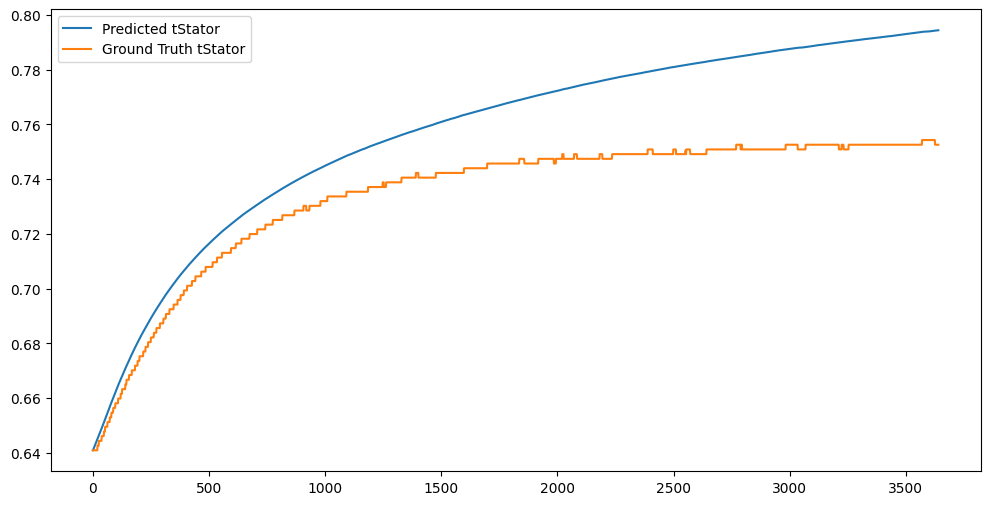

In [42]:
index = 2

pred_arr = pred[:, index, :]
gt_arr = test_tensor[:, index, -len(configs['target_cols']):].cpu().numpy()

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(pred_arr[:, -4], label='Predicted tStator')
ax.plot(gt_arr[:, -4], label='Ground Truth tStator')
ax.legend()